In [ ]:

# LDA IMPLEMENTATION: 
# Implement Linear Discriminant Analysis (LDA) from scratch in Python without using any built-in 
# LDA functions (e.g., sklearn.discriminant_analysis.LinearDiscriminantAnalysis). 
# Your implementation should: 
# 1.Compute the class-wise means and the overall mean. 
# 2.Construct the Within-Class Scatter Matrix (𝑆𝑊). 
# 3.Construct the Between-Class Scatter Matrix (𝑆𝐵). 
# 4.Solve the generalized eigenvalue problem for 𝑆𝑊−1𝑆𝐵. 
# 5.Select the top 𝑘discriminant vectors based on the largest eigenvalues. 
# 6.Project the given dataset onto the new lower-dimensional subspace. 
# 7.Visualize the transformed data for a two-class or multi-class dataset. 
# Restrictions:
# •	You may use NumPy for matrix operations and Matplotlib for visualization. 
# •	Do not use any built-in LDA implementation from Scikit-learn or other machine learning 
# libraries. 
# •
# Clearly comment each step of your code and explain the role of 𝑆𝑊, 𝑆𝐵, eigenvalues, and eigenvectors in the LDA process. 

# Expected Output:
# •	Reduced-dimensional feature matrix. 
# •	Plot showing the projected samples. 
# •	Brief explanation of how LDA maximizes class separability. 


Class means: {np.int64(0): array([3. , 3.8]), np.int64(1): array([8.4, 7.6])}
Sw:
 [[13.2 -1.2]
 [-1.2 22. ]]
SB:
 [[72.9 51.3]
 [51.3 36.1]]
Eigenvalues: [ 7.62541528e+00 -2.22044605e-16]
Top discriminant vector(s):
 [[0.90878558]
 [0.41726342]]
Projected data:
 [ 4.46966918  3.48662485  3.06936143  5.22993727  5.30419602 12.35170446
  8.79082087 10.26538736 10.19112861 12.4259632 ]


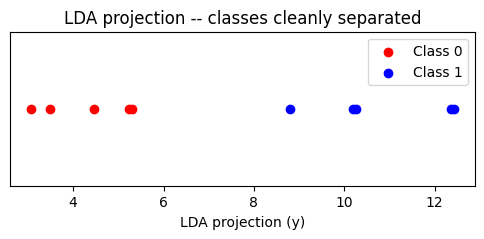

In [2]:
import numpy as np
import matplotlib.pyplot as plt
 
# ---- Sample two-class dataset ----
X1 = np.array([[4,2],[2,4],[2,3],[3,6],[4,4]])     # class 0
X2 = np.array([[9,10],[6,8],[9,5],[8,7],[10,8]])   # class 1
X = np.vstack([X1, X2])
y = np.array([0]*5 + [1]*5)
 
classes = np.unique(y)
n_features = X.shape[1]
 
# 1. Class-wise means and the overall mean
mean_overall = X.mean(axis=0)
mean_vectors = {c: X[y == c].mean(axis=0) for c in classes}
 
# 2. Within-Class Scatter Matrix (Sw)
#    Sw measures how spread out each class is around its OWN mean.
#    Summing over classes gives the total "noise"/spread we want to minimize.
Sw = np.zeros((n_features, n_features))
for c in classes:
    Xc = X[y == c]
    mc = mean_vectors[c]
    Sw += (Xc - mc).T @ (Xc - mc)          # sum (x-mu_c)(x-mu_c)^T
 
# 3. Between-Class Scatter Matrix (SB)
#    SB measures how far each class mean is from the OVERALL mean,
#    weighted by how many samples are in that class.
SB = np.zeros((n_features, n_features))
for c in classes:
    Nc = X[y == c].shape[0]
    diff = (mean_vectors[c] - mean_overall).reshape(-1, 1)
    SB += Nc * (diff @ diff.T)
 
# 4. Solve the generalized eigenvalue problem for Sw^-1 SB
#    Eigenvectors = candidate projection directions.
#    Eigenvalues  = how much class separation each direction achieves
#    (this is exactly J(w), the Fisher criterion, for that direction).
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw).dot(SB))
eigvals = eigvals.real
eigvecs = eigvecs.real
 
# 5. Select the top k discriminant vectors (k = min(features, classes-1))
k = min(n_features, len(classes) - 1)
order = np.argsort(eigvals)[::-1]        # descending by eigenvalue
W = eigvecs[:, order[:k]]                 # top-k eigenvectors as columns
 
# 6. Project the data onto the new (lower-dimensional) subspace
X_lda = X.dot(W)
 
print("Class means:", mean_vectors)
print("Sw:\n", Sw)
print("SB:\n", SB)
print("Eigenvalues:", eigvals)
print("Top discriminant vector(s):\n", W)
print("Projected data:\n", X_lda.ravel())
 
# 7. Visualize (1D projection -> plot along a single axis, colored by class)
plt.figure(figsize=(6,2))
plt.scatter(X_lda[y==0], np.zeros(5), c="red", label="Class 0")
plt.scatter(X_lda[y==1], np.zeros(5), c="blue", label="Class 1")
plt.yticks([])
plt.xlabel("LDA projection (y)")
plt.legend()
plt.title("LDA projection -- classes cleanly separated")
plt.show()
